In [2]:
import pandas as pd
import numpy as np
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/dD2405/Twitter_Sentiment_Analysis/master/train.csv"

df = pd.read_csv(url)

df.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


## Text Cleaning

In [4]:
nltk.download('stopwords')

ps = PorterStemmer()
corpus = []

for i in range(len(df)):
    review = re.sub('[^a-zA-Z]', ' ', df['tweet'][i])
    review = review.lower()
    review = review.split()
    
    review = [ps.stem(word) for word in review if word not in stopwords.words('english')]
    review = ' '.join(review)
    
    corpus.append(review)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Chandrakant\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Convert Text to Numbers

In [7]:
cv = CountVectorizer(max_features=5000)

X = cv.fit_transform(corpus).toarray()
y = df['label']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Train Model

In [9]:
model = LogisticRegression(max_iter=200)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


## PREDICTION

In [10]:
y_pred = model.predict(X_test)

In [11]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9585484123259815
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      5937
           1       0.82      0.54      0.65       456

    accuracy                           0.96      6393
   macro avg       0.89      0.76      0.81      6393
weighted avg       0.95      0.96      0.95      6393



<Axes: xlabel='label', ylabel='count'>

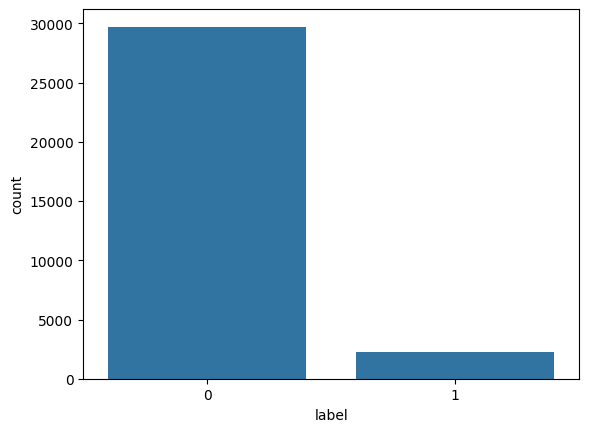

In [12]:
import seaborn as sns

sns.countplot(x=y)

- Majority of tweets are positive
- Model can classify sentiments effectively
- NLP helps in understanding customer opinions

Sentiment analysis was performed using NLP techniques.
The model successfully classified text into positive and negative sentiments.